# **Olist Project**
**Insights from Olist’s dataset**

**Objective**

In this project we will explore the Brazilian E-Commerce Public Dataset by Olist and conduct basic statistical analysis and A/B testing to draw insights from the data.At the end of the day, you will have the opportunity to present you work with the rest of the batch.

**Dataset**

You can find the data [here](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) and if you want to learn more about this dataset or use more data, you can visit the Kaggle page [here](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce).

You might notice some differences between the version you can download and the Kaggle version. That’s because we have reduced the scope of the dataset by dropping some tables in order to make this project achievable in one day!

There is no notebook for this day, you need to create your own! We only have one piece of advice: keep things organized. At the end of the day, after you’ve written a lot of code, you need to still be able to make sense of it and present it to your peers!

**Dataset Description**

The Brazilian E-Commerce Public Dataset by Olist contains information about orders, customers, products, and payments from 2016 to 2018. It includes data on orders made at Olist Store, which is divided into multiple datasets linked by unique identifiers.

**Project Steps**

1. Data Exploration and Preparation

2. Descriptive Statistics

    - Order Price Statistics

    - Product Category Distribution

    - Shipping Time Statistics

    - Customer Satisfaction Ratings

    By studying correlations, you can uncover insights into the relationships between different variables in the dataset, which can inform business decisions and strategies for improving customer experience and satisfaction.


3. Hypothesis Testing (A/B Testing)

    - Testing the Effect of Shipping Time on Customer Satisfaction

    - Testing the Impact of Product Category on Order Value

    - Testing the Impact of Payment Method on Order Completion Rate

4. Visualization and Interpretation

5. Conclusion and Next Steps

## **1. Data Exploration and Preparation**

- Load the necessary Python libraries (pandas, numpy, plotly express).
- Load the dataset into a pandas DataFrame.
- Explore the structure of the dataset (columns, datatypes, missing values).
- Clean the data (handle missing values, data type conversions if necessary).


In [1]:
# import
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

In [2]:
# dataframes
costumers = pd.read_csv('raw_data/olist_customers_dataset.csv')
order_items = pd.read_csv('raw_data/olist_order_items_dataset.csv')
payments = pd.read_csv('raw_data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('raw_data/olist_order_reviews_dataset.csv')
orders = pd.read_csv('raw_data/olist_orders_dataset.csv')
products = pd.read_csv('raw_data/olist_products_dataset.csv')
sellers = pd.read_csv('raw_data/olist_sellers_dataset.csv')

In [3]:
# to test for types and null values
df_list =  [costumers, order_items, payments, reviews, orders, products, sellers]

name_list =  ['costumers', 'order_items', 'payments', 'reviews', 'orders', 'products', 'sellers']


for df, name in zip(df_list, name_list):

    print(f'Dataframe {name} Datatypes: {df.dtypes}')
    print(f'There are {len(df)} rows')
    print(f'Null values: {df.isnull().sum()}')

Dataframe costumers Datatypes: customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object
There are 99441 rows
Null values: customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Dataframe order_items Datatypes: order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object
There are 112650 rows
Null values: order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
Dataframe payments Datatypes: order_id                 object
payment_sequential        int64
pa

## **2. Descriptive Statistics**

By examining descriptive statistics, you can gain a comprehensive understanding of the dataset’s characteristics and identify areas of interest for further analysis or improvement.

- Compute basic statistics (mean, median, mode, standard deviation) for relevant columns (e.g., order price).
- Visualize distributions using histograms, boxplots, etc.
- Explore correlations between variables.

A few examples of descriptive statistics that can be computed and visualized from the dataset.

### 2.1 Order Price Statistics

- **Mean order price:** This represents the average amount spent per order.$X
- **Median order price:** This is the middle value of the order prices when they are sorted in ascending order. It’s a measure of central tendency that is less affected by outliers compared to the mean. $Y
- **Standard deviation of order prices:** This measures the dispersion or variability of order prices around the mean. A higher standard deviation indicates more variability in order prices.$Z
- **Histogram of order prices showing the distribution:** This visualizes the distribution of order prices, showing how frequently different price ranges occur.

In [4]:
order_items_groupby =  order_items.groupby('order_id').price.sum().reset_index()

mean = order_items_groupby.price.mean().round(2)
median = order_items_groupby.price.median().round(2)
std = order_items_groupby.price.std().round(2)

print(f'The mean price for Olist is {mean}, the median is {median} and the standard deviation of price is {std}.')

The mean price for Olist is 137.75, the median is 86.9 and the standard deviation of price is 210.65.


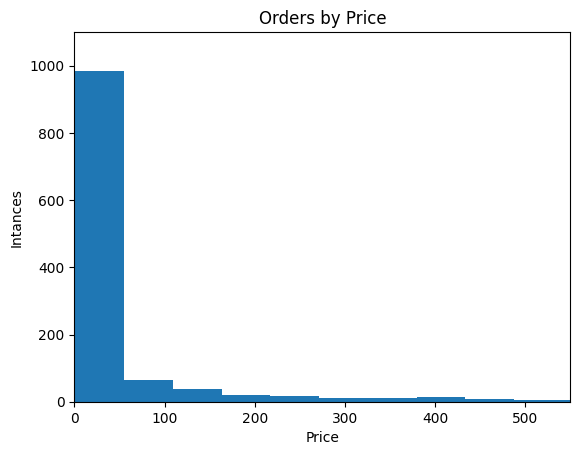

In [5]:
order_items_groupby['price'] = order_items_groupby['price'].round()

order_items_groupby_2 = order_items_groupby.groupby('price').order_id.count().reset_index()
order_items_groupby_2.rename(columns={'order_id': 'instances'}, inplace = True)

plt.hist(order_items_groupby_2['instances'], bins=50)
plt.title('Orders by Price')
plt.xlabel('Price')
plt.ylabel('Intances')
plt.xlim(0,550)
plt.ylim(0,1100)
plt.show()

### 2.2 Product Category Distribution

- **Bar chart:** To show the number of orders placed in each product category. It helps identify which categories are most popular among customers.
- **Payment Method Distribution Pie Chart:** This illustrates the proportion of orders made using different payment methods, such as credit card, debit card, or boleto (Brazilian payment method).


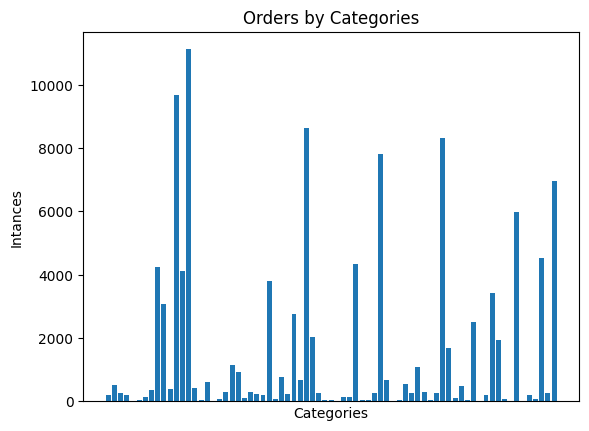

In [6]:
order_items_products = order_items.merge(products, how='left', on='product_id')
order_items_products_groupby = order_items_products.groupby('product_category_name').product_id.count().reset_index()
order_items_products_groupby.rename(columns={'product_id': 'instances'}, inplace = True)

plt.bar(order_items_products_groupby['product_category_name'],order_items_products_groupby['instances'])
plt.title('Orders by Categories')
plt.xlabel('Categories')
plt.ylabel('Intances')
plt.xticks([])
plt.show()

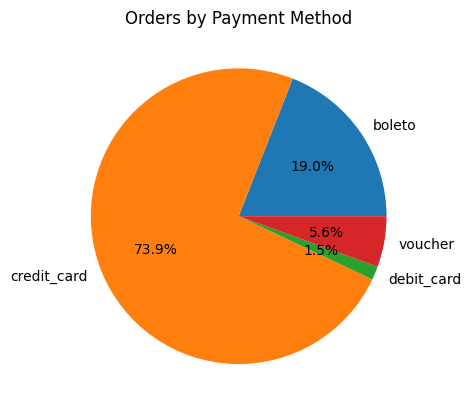

In [7]:
payments_groupby = payments.groupby('payment_type').order_id.count().reset_index()
payments_groupby.rename(columns={'order_id': 'instances'}, inplace = True)
payments_groupby = payments_groupby[payments_groupby['payment_type'] != 'not_defined']
plt.pie(payments_groupby['instances'], labels= payments_groupby['payment_type'], autopct='%1.1f%%')
plt.title('Orders by Payment Method')
plt.show()

### 2.3 Shipping Time Statistics

- **Mean shipping time:** This gives the average time taken for orders to be delivered to customers. D days
- **Median shipping time:** Similar to the median for order price, this represents the middle value of shipping times. E days
- **Standard deviation of shipping times:** This measures the variability in shipping times. F days
- **Boxplot of shipping times:** This visualizes the spread of shipping times, showing the minimum, maximum, median, and outliers.


The average time to deliver for Olist is 12 days 13:24:31.879068369, the median is 10 days 05:13:34 and the standard deviation of time to deliver is 9 days 13:07:00.181125305.


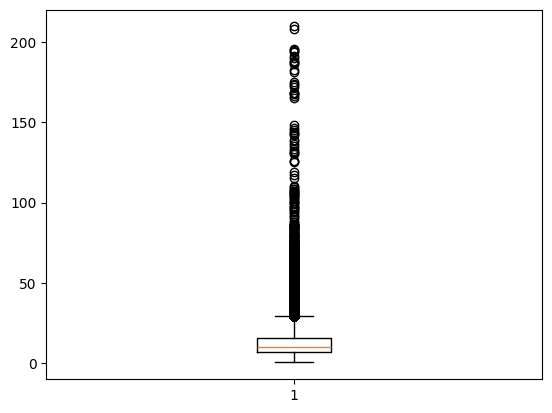

In [8]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['deliver_time'] = orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']

mean = orders.deliver_time.mean()
median = orders.deliver_time.median()
std = orders.deliver_time.std()

print(f'The average time to deliver for Olist is {mean}, the median is {median} and the standard deviation of time to deliver is {std}.')

orders['deliver_time_days']  = orders['deliver_time'].dt.total_seconds() / (60 * 60 * 24) 

plt.boxplot(orders['deliver_time_days'].dropna())
plt.show()

### 2.4 Customer Satisfaction Ratings

- **Mean satisfaction rating:** This gives the average satisfaction rating across all orders.
- **Median satisfaction rating:** Proportion of satisfied (rating >= 4) vs. dissatisfied customers (rating < 4).
- **Proportion of satisfied vs. dissatisfied customers:** This shows the percentage of customers who rated their satisfaction as high (4 or 5) versus low (1 to 3), providing insights into overall customer satisfaction levels.

In [9]:
mean = reviews.review_score.mean()

satified_count = (reviews['review_score'] >=4).sum()
total = len(reviews)

satisfied_percent = satified_count / total * 100


print(f'The average review score for Olist is {mean}, {satisfied_percent}% of costumers are satisfied.')

The average review score for Olist is 4.08642062404257, 77.06804805289042% of costumers are satisfied.


### **Questions**

- **Order Price vs. Shipping Time**: Is there a correlation between the amount spent on orders and the time taken for shipping?

This analysis could show whether customers who spend more are more or less tolerant of longer shipping times.


The correlation between Price and Delivery Time is 0.055587918051224226


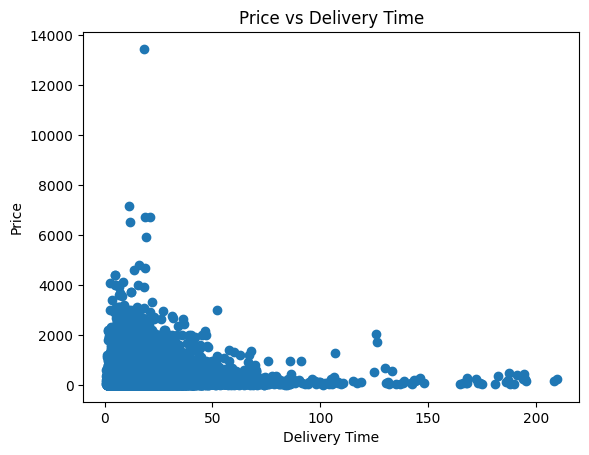

In [10]:
orders_plus = orders.merge(order_items_groupby, how='left', on='order_id')

corr = orders_plus.deliver_time_days.corr(orders_plus.price)
print(f'The correlation between Price and Delivery Time is {corr}')

plt.scatter(orders_plus.deliver_time_days, orders_plus.price)
plt.title('Price vs Delivery Time')
plt.xlabel('Delivery Time')
plt.ylabel('Price')
plt.show()

- **Order Price vs. Customer Satisfaction Rating**: Is there a correlation between the amount spent on orders and the satisfaction rating given by customers?

This analysis could indicate whether customers who spend more are generally more satisfied with their purchases.


The correlation between Price and Customer Satisfaction is -0.039681825862708756


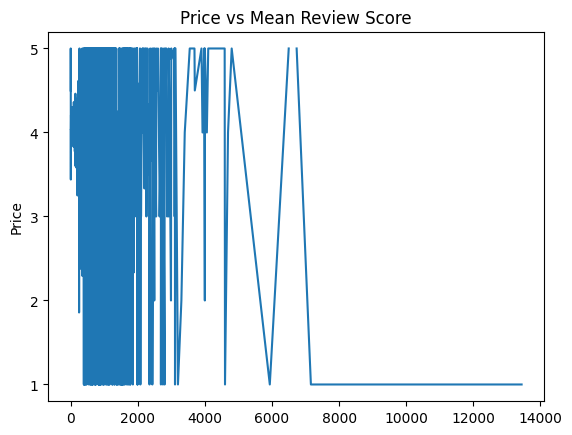

In [11]:
orders_items_reviews = order_items_groupby.merge(reviews, how='left', on='order_id')

corr = orders_items_reviews.price.corr(orders_items_reviews.review_score)

print(f'The correlation between Price and Customer Satisfaction is {corr}')

orders_items_reviews['price'] = orders_items_reviews['price'].round()

orders_items_reviews_groupby = orders_items_reviews.groupby('price').review_score.mean().reset_index()


plt.plot(orders_items_reviews_groupby.price, orders_items_reviews_groupby.review_score)
plt.title('Price vs Mean Review Score')
plt.yticks(range(1,6))
plt.ylabel('Review Score')
plt.ylabel('Price')
plt.show()

- **Product Category vs. Customer Satisfaction Rating**: Is there a correlation between the product category and the satisfaction rating given by customers?

This analysis could show whether customers have varying satisfaction levels depending on the type of product they purchase.

The correlation Product Category and Customer Satisfaction is -0.0063875947795283845


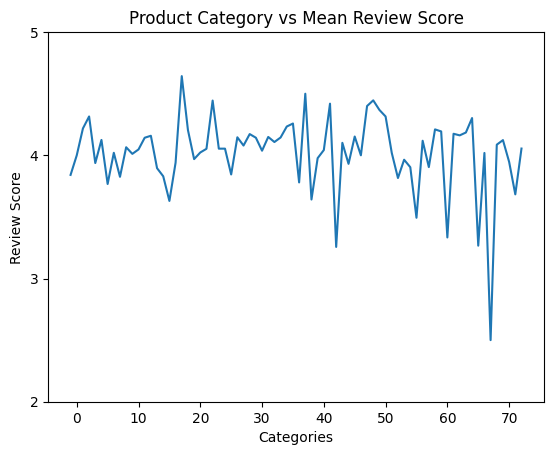

In [12]:
order_items_products_reviews =  order_items_products.merge(reviews, how='left', on='order_id')

order_items_products_reviews['product_category_number'] = order_items_products_reviews['product_category_name'].astype('category').cat.codes

corr = order_items_products_reviews.product_category_number.corr(order_items_products_reviews.review_score)

print(f'The correlation Product Category and Customer Satisfaction is {corr}')


order_items_products_reviews_groupby = order_items_products_reviews.groupby('product_category_number').review_score.mean().reset_index()


plt.plot(order_items_products_reviews_groupby.product_category_number, order_items_products_reviews_groupby.review_score)
plt.title('Product Category vs Mean Review Score')
plt.yticks(range(1,6))
plt.ylim(2,5)
plt.xlabel('Categories')
plt.ylabel('Review Score')
plt.show()

- **Payment Method vs. Customer Satisfaction Rating**: Is there a correlation between the payment method used and the satisfaction rating given by customers?

This analysis could reveal whether customers who use certain payment methods are more satisfied with their purchases than others.

The correlation Payment Type and Customer Satisfaction is -0.011299264531428214


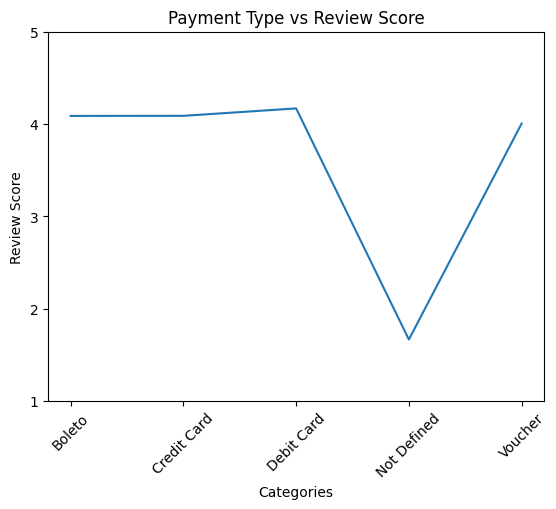

In [13]:
payments_reviews = payments.merge(reviews, how='left', on='order_id')

payments_reviews['payment_number'] = payments_reviews['payment_type'].astype('category').cat.codes

corr = payments_reviews.payment_number.corr(payments_reviews.review_score)

print(f'The correlation Payment Type and Customer Satisfaction is {corr}')

payments_reviews_groupby = payments_reviews.groupby(['payment_number', 'payment_type']).review_score.mean().reset_index()


plt.plot(payments_reviews_groupby.payment_number, payments_reviews_groupby.review_score)
plt.title('Payment Type vs Review Score')
plt.yticks(range(1,6))
plt.xticks(
    ticks=payments_reviews_groupby['payment_number'],
    labels=payments_reviews_groupby['payment_type'].str.replace('_',' ').str.title(),
    rotation=45
)
plt.xlabel('Categories')
plt.ylabel('Review Score')
plt.show()

- **Shipping Time vs. Customer Satisfaction Rating** Is there a correlation between the time taken for shipping and the satisfaction rating given by customers?

This analysis could indicate whether faster shipping leads to higher satisfaction levels among customers.

The correlation Delivery Time and Customer Satisfaction is -0.3338040907668426


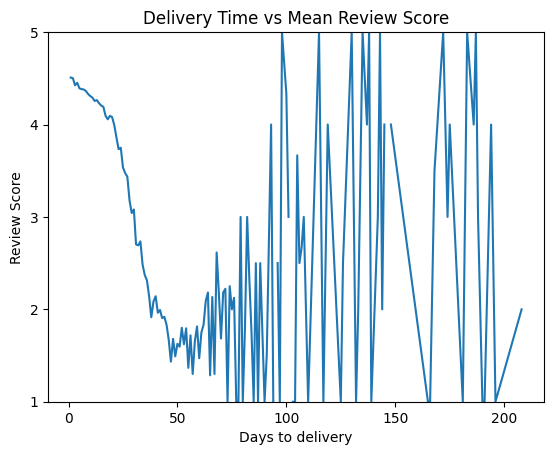

In [14]:
orders_reviews = orders.merge(reviews, how='left', on='order_id')

corr = orders_reviews.deliver_time_days.corr(orders_reviews.review_score)

print(f'The correlation Delivery Time and Customer Satisfaction is {corr}')

orders_reviews['deliver_time_days'] = orders_reviews['deliver_time_days'].round()


orders_reviews_groupby = orders_reviews.groupby('deliver_time_days').review_score.mean().reset_index()

plt.plot(orders_reviews_groupby.deliver_time_days, orders_reviews_groupby.review_score)
plt.title('Delivery Time vs Mean Review Score')
plt.yticks(range(1,6))
plt.ylim(1,5)
plt.xlabel('Days to delivery')
plt.ylabel('Review Score')
plt.show()

## **3. Hypothesis Testing (A/B Testing)**

### 3.1 Testing the Effect of Shipping Time on Customer Satisfaction

- **Hypothesis 1:**

    - **Null Hypothesis (H0):** There is no difference in customer satisfaction between orders delivered on time and orders delivered late.
    - **Alternative Hypothesis (H1):** Orders delivered on time have higher customer satisfaction compared to orders delivered late.

- **A/B Testing Process:**

    - Divide the dataset into two groups: one group with orders delivered before or on the estimated delivery time and the other with orders delivered after the estimated delivery time.
    - Compute the average satisfaction rating for each group.
    - Conduct a hypothesis test (e.g., t-test) to determine if there is a statistically significant difference in satisfaction ratings between the two groups.

In [15]:
orders_reviews['order_estimated_delivery_date'] = pd.to_datetime(orders_reviews['order_estimated_delivery_date'])
orders_reviews['ontime'] = (orders_reviews['order_delivered_customer_date'] < orders_reviews['order_estimated_delivery_date']).astype(int)

on_time = orders_reviews[orders_reviews['ontime'] == 1]['review_score'].dropna() 
out_time = orders_reviews[orders_reviews['ontime'] == 0]['review_score'].dropna()

on_time_score = on_time.mean()
out_time_score = out_time.mean()

print(f'The average review score for deliveries on time is {on_time_score}, but when the delivery is late the score is {out_time_score}')

t_stat, p_value = stats.ttest_ind(a=on_time, b=out_time, equal_var=True)

print(f'The p value is for t test is {p_value}')

The average review score for deliveries on time is 4.293577567732184, but when the delivery is late the score is 2.3481923149725534
The p value is for t test is 0.0


### 3.2 Testing the Impact of Product Category on Order Value

- **Hypothesis 2:**

    - **Null Hypothesis (H0):** There is no difference in the average order value between different product categories.
    - **Alternative Hypothesis (H1):** Some product categories have higher average order values compared to others.

- **A/B Testing Process:**

    - Divide the dataset into groups based on product categories.
    - Compute the average order value for each product category.
    - Conduct a hypothesis test (e.g., ANOVA test) to determine if there is a statistically significant difference in average order values across different product categories.
    
- **Interpretation:**

    - If the p-value is less than the chosen significance level, reject the null hypothesis and conclude that there is a significant difference in average order values across product categories.
    - If the p-value is greater than the significance level, fail to reject the null hypothesis, indicating no significant difference in average order values between product categories.


In [16]:

order_items_products['product_category_number'] = order_items_products['product_category_name'].astype('category').cat.codes

a_score, p_value = stats.f_oneway(order_items_products['product_category_number'], order_items_products['price'])

print(f'The p value is for anova test is {p_value}')


The p value is for anova test is 0.0


### 3.3 Testing the Impact of Payment Method on Order Completion Rate:

- **Hypothesis 3:**
    - **Null Hypothesis (H0):** There is no difference in the completion rate between orders paid via credit card and orders paid via boleto (Brazilian payment method).
    - **Alternative Hypothesis (H1):** Orders paid via credit card have a higher completion rate compared to orders paid via boleto.

- **A/B Testing Process:**

    - Divide the dataset into two groups based on payment methods: credit card and boleto.
    - Calculate the completion rate (percentage of orders successfully completed) for each group.
    - Conduct a hypothesis test (e.g., chi-square test) to determine if there is a statistically significant difference in completion rates between the two payment methods.

- **Interpretation:**

    - If the p-value is less than the chosen significance level, reject the null hypothesis and conclude that there is a significant difference in completion rates between credit card and boleto payments.
    - If the p-value is greater than the significance level, fail to reject the null hypothesis, indicating no significant difference in completion rates between the two payment methods.

**Answer:** 

- There is no data in the datasets to answer the order completion rate. All payments types have 100% completion rate. The data of clicks, baskets and  purchases are not available.

## **4. Visualization and Interpretation**

- Visualize the results of hypothesis testing (e.g., bar chart comparing satisfaction rates between control and treatment groups).
- Interpret the visualizations and relate them back to the hypothesis being tested.
- Discuss any implications or insights from the analysis.

### 4.1 The Effect of Shipping Time on Customer Satisfaction

Text(0, 0.5, 'Costumer Satisfaction Score')

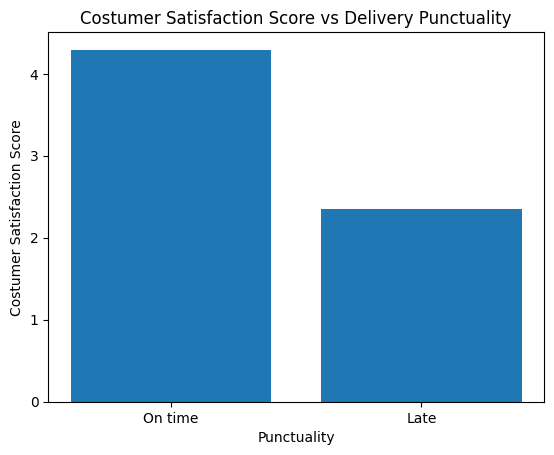

In [17]:
name = ['On time', 'Late']
case = [on_time_score, out_time_score]

plt.bar(name, case) 
plt.title('Costumer Satisfaction Score vs Delivery Punctuality')
plt.xlabel('Punctuality')
plt.ylabel('Costumer Satisfaction Score')

### 4.2 The Impact of Product Category on Order Value

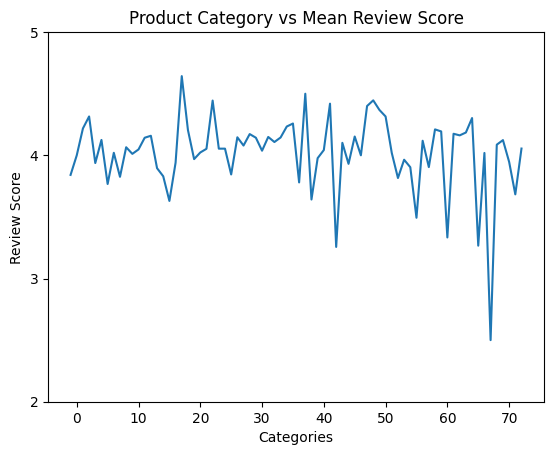

In [18]:
order_items_products_reviews =  order_items_products.merge(reviews, how='left', on='order_id')

order_items_products_reviews['product_category_number'] = order_items_products_reviews['product_category_name'].astype('category').cat.codes

order_items_products_reviews_groupby = order_items_products_reviews.groupby('product_category_number').review_score.mean().reset_index()

plt.plot(order_items_products_reviews_groupby.product_category_number, order_items_products_reviews_groupby.review_score)
plt.title('Product Category vs Mean Review Score')
plt.yticks(range(1,6))
plt.ylim(2,5)
plt.xlabel('Categories')
plt.ylabel('Review Score')
plt.show()

## **5. Conclusion and Next Steps**

- Summarize the findings from the analysis.
- Discuss limitations of the analysis and potential areas for further exploration.

- The effect on customer satisfaction by the shipping time is notorios and proved by the t test, to get high satisfaction values Olist must deliver on time.

- Some products categories have a clear disadvantage agaisnt others, maybe some products in this categories have very low satisfactions rates and caused the role category to be deficient. Need further investigation to get to the bottom of the problem.